In [1]:
import pandas as pd
import numpy as np
from pynm import pynm
import seaborn as sns
import matplotlib.pyplot as plt

import patsy as pat
import statsmodels.api as sm

## **Generate multisite data**
### Randomize metadata for each site cohort

In [2]:
np.random.seed(666)
n_sites = 5
age_min = (np.random.rand(n_sites)*50).astype(int)
sites = pd.DataFrame(data={'sex_ratio': np.random.rand(n_sites),
                           'prob_ratio': 0.5*np.random.rand(n_sites),
                           'age_min': age_min,
                           'age_max': (age_min+5+np.random.rand(n_sites)*50).astype(int),
                           'score_shift': np.random.randn(n_sites)/4,
                           'sample_size': (100000+np.random.rand(n_sites)*500).astype(int)})
sites

,sex_ratio,prob_ratio,age_min,age_max,score_shift,sample_size
0,0.012703,0.100124,35,78,-0.272198,100444
1,0.413588,0.372077,42,47,-0.143943,100313
2,0.048813,0.096446,33,43,-0.420725,100409
3,0.099929,0.350422,36,46,0.057296,100273
4,0.508066,0.146614,47,64,-0.439156,100208


### Define implicit models

In [3]:
def model(age,sex,offset):
    noise = np.random.normal(0,0.1)
    return 0.001*age-0.00001*(age-50)**2+0.5 + noise - np.random.uniform(0,0.3)*sex + offset

#Same model for probands, w/ more extreme noise and small random shift down
def model_prob(age,sex,offset):
    noise = np.random.normal(0,0.1)
    return 0.001*age-0.00001*(age-50)**2+0.5 + noise - np.random.uniform(0,0.3)*sex -0.2*np.random.uniform() + offset

### Generate fake participant data

In [4]:
participants = []
for site in sites.iterrows():
    print(f'Processing site # {site[0]}')
    for participant in range(int(site[1]['sample_size'])):
        #sex = np.random.rand()>site[1]['sex_ratio']
        sex = np.random.binomial(1,site[1]['sex_ratio'])
        prob = np.random.binomial(1,site[1]['prob_ratio'])
        #age = site[1]['age_min'] + np.random.rand() * (site[1]['age_max']-site[1]['age_min'])
        age = np.random.uniform(site[1]['age_min'],site[1]['age_max'])
        if prob:
            score = model_prob(age,sex,site[1]['score_shift'])
        else:
            score = model(age,sex,site[1]['score_shift'])
        participants.append([site[0], sex,prob, age, score])

Processing site # 0
Processing site # 1
Processing site # 2
Processing site # 3
Processing site # 4


In [5]:
df=pd.DataFrame(participants, columns=['site', 'sex','group', 'age', 'score'])
df.sex.replace({1: 'Female', 0: 'Male'}, inplace=True)
df.group.replace({1: 'PROB', 0: 'CTR'}, inplace=True)
df

,site,sex,group,age,score
0,0,Male,CTR,38.232161,0.349112
1,0,Male,CTR,55.931562,0.313037
2,0,Male,CTR,73.802357,0.264671
3,0,Male,CTR,35.697482,0.162974
4,0,Male,CTR,53.062359,0.145542
...,...,...,...,...,...
501642,4,Male,CTR,49.519782,0.297675
501643,4,Female,CTR,50.708895,-0.196421
501644,4,Male,CTR,56.593362,0.199917
501645,4,Female,PROB,49.278350,-0.152767


/Users/kwisatz/opt/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


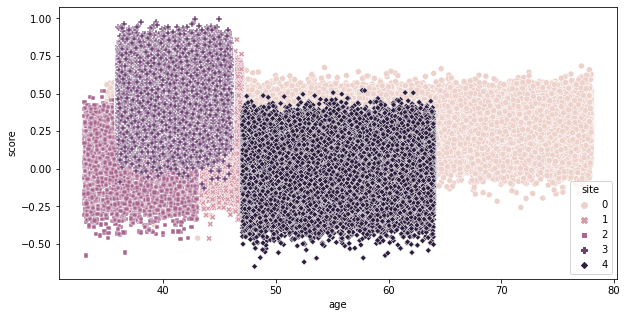

In [6]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='age', y='score', hue='site', style='site')
plt.show()

In [7]:
ctr = df.loc[(df["group"] == "CTR")]
ctr_mask = df.index.isin(ctr.index)
probands = df.loc[(df["group"] == "PROB")]
prob_mask = df.index.isin(probands.index)

confounds, categorical = pynm.read_confounds(['age','C(sex)','C(site)'])
conf_mat = df[confounds]
conf_mat = pd.get_dummies(conf_mat,columns=categorical,drop_first=True)
conf_mat_cols = conf_mat.columns.tolist()
conf_mat = conf_mat.to_numpy()

y = df["score"][ctr_mask].to_numpy().reshape(-1,1)
X = conf_mat[ctr_mask]

In [8]:
import gpflow
from gpflow.utilities import print_summary
import tensorflow as tf
import itertools
from gpflow.ci_utils import ci_niter

tf.random.set_seed(42)
np.random.seed(42)

length_scale=1
nu=2.5

M = 50  # Number of inducing locations
N = X.shape[0]

kernel = gpflow.kernels.Matern12(variance=nu, lengthscales=length_scale) + gpflow.kernels.Constant() + gpflow.kernels.White(1)

Z = X[:M, :].copy()  # Initialize inducing locations to the first M inputs in the dataset
m = gpflow.models.SVGP(kernel, gpflow.likelihoods.Gaussian(), Z, num_data=N)
elbo = tf.function(m.elbo)

data = (X, y)
tensor_data = tuple(map(tf.convert_to_tensor, data))

In [9]:
%%timeit
elbo(tensor_data)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
424 ms ± 3.28 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
minibatch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices((X, y)).repeat().shuffle(N)
train_iter = iter(train_dataset.batch(minibatch_size))
ground_truth = elbo(tensor_data).numpy()

In [11]:
%%timeit
elbo(next(train_iter))

The slowest run took 4.72 times longer than the fastest. This could mean that an intermediate result is being cached.
2.07 ms ± 1.67 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
# We turn off training for inducing point locations
gpflow.set_trainable(m.inducing_variable, False)


def run_adam(model, iterations):
    """
    Utility function running the Adam optimizer

    :param model: GPflow model
    :param interations: number of iterations
    """
    # Create an Adam Optimizer action
    logf = []
    train_iter = iter(train_dataset.batch(minibatch_size))
    training_loss = model.training_loss_closure(train_iter, compile=True)
    optimizer = tf.optimizers.Adam()

    @tf.function
    def optimization_step():
        optimizer.minimize(training_loss, model.trainable_variables)

    for step in range(iterations):
        optimization_step()
        if step % 10 == 0:
            elbo = -training_loss().numpy()
            logf.append(elbo)
    return logf

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
CPU times: user 43.5 s, sys: 9.63 s, total: 53.1 s
Wall time: 22.8 s


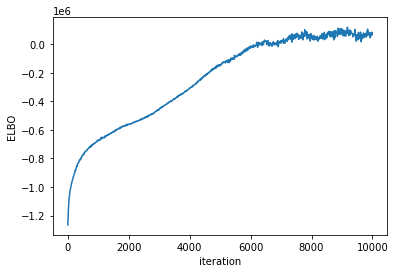

In [13]:
%%time
maxiter = ci_niter(10000)

logf = run_adam(m, maxiter)
plt.plot(np.arange(maxiter)[::10], logf)
plt.xlabel("iteration")
_ = plt.ylabel("ELBO")

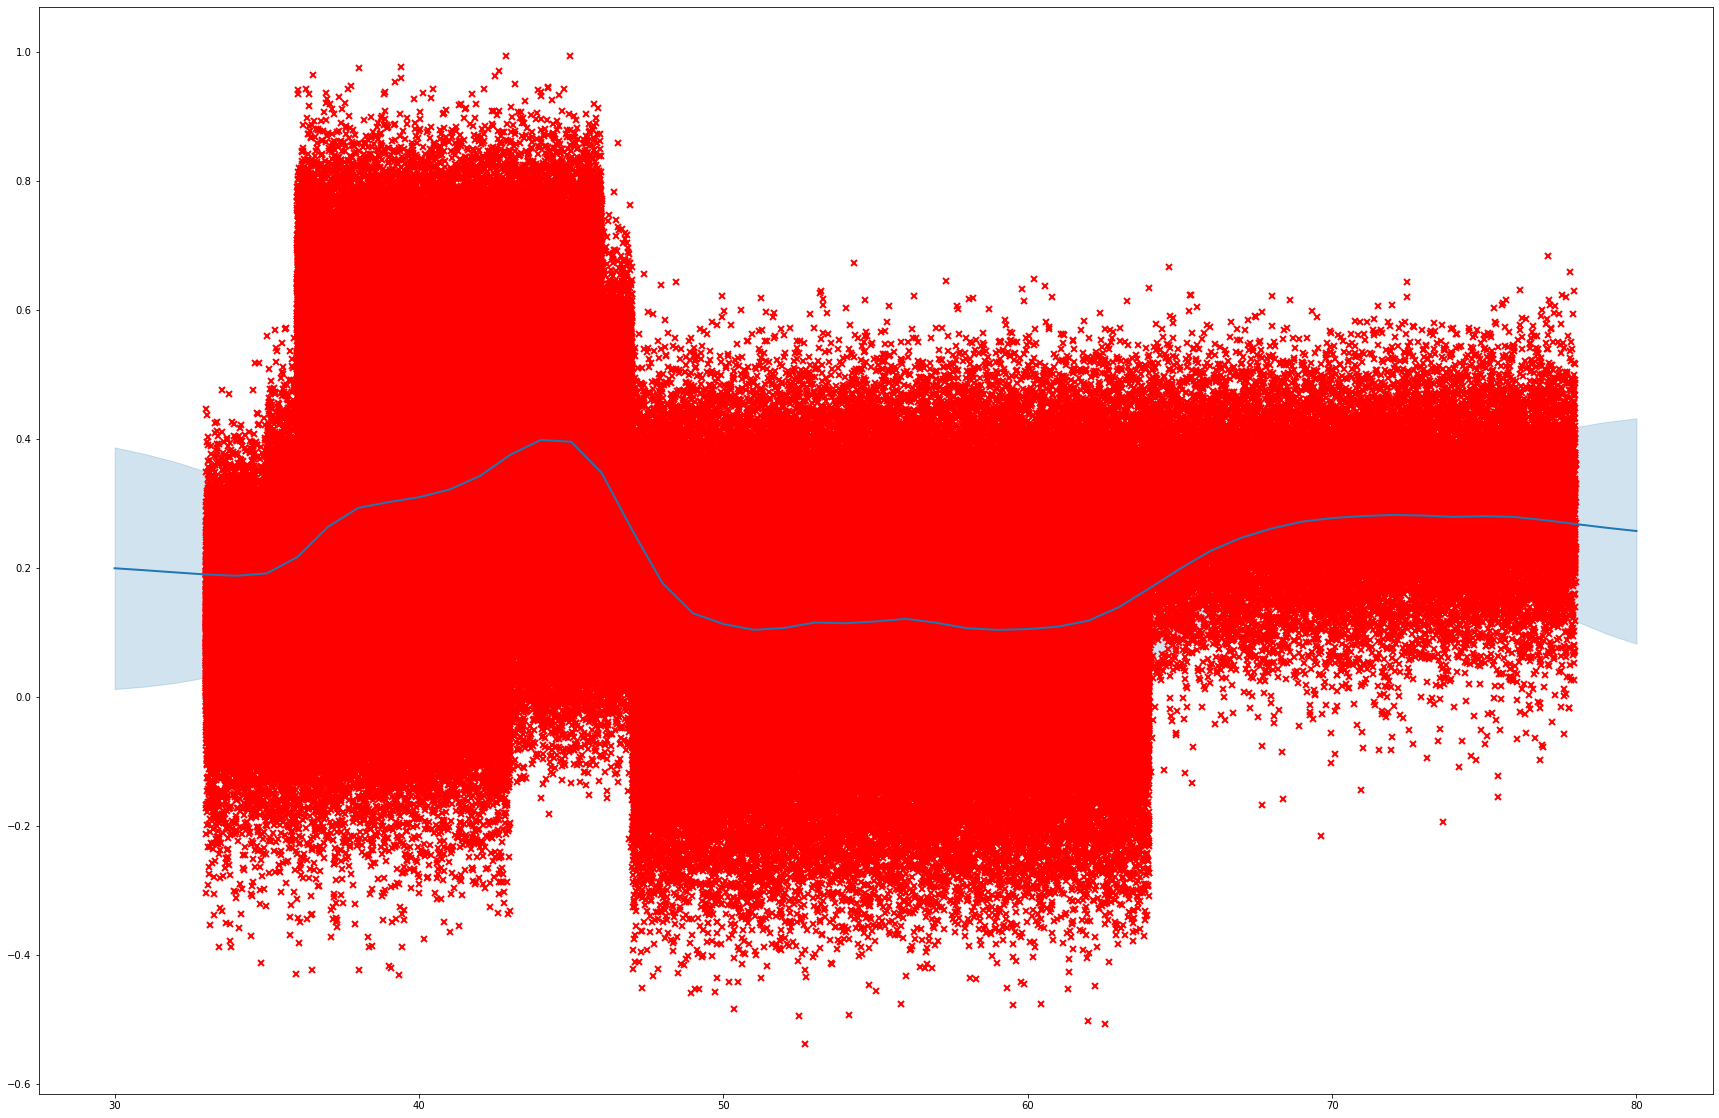

In [14]:
a = np.linspace(30, 80, 51).reshape(51, 1)
b = np.ones((51,5)) * 0.5
xx = np.hstack((a, b))

## predict mean and variance of latent GP at test points
mean, var = m.predict_f(xx)

## plot
plt.figure(figsize=(30, 20))
plt.plot(X[:, 0], y, "rx", mew=2)
plt.plot(xx[:, 0], mean, "C0", lw=2)
plt.fill_between(
    xx[:, 0],
    mean[:, 0] - 1.96 * np.sqrt(var[:, 0]),
    mean[:, 0] + 1.96 * np.sqrt(var[:, 0]),
    color="C0",
    alpha=0.2,
)

# ## generate 10 samples from posterior
#   # for reproducibility
# samples = m.predict_f_samples(X, 10)  # shape (10, 100, 1)
# plt.plot(X[:, 0], samples[:, :, 0].numpy().T, "bo", linewidth=0.5)

plt.show()

In [ ]:
%%time
import gpflow
from gpflow.utilities import print_summary
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

length_scale=1
nu=2.5

kernel = gpflow.kernels.Matern12(variance=nu, lengthscales=length_scale) + gpflow.kernels.Constant() + gpflow.kernels.White(1)
m = gpflow.models.GPR(data=(X, y), kernel=kernel, mean_function=None)

opt = gpflow.optimizers.Scipy()
opt_logs = opt.minimize(m.training_loss, m.trainable_variables, options=dict(maxiter=10000))
print_summary(m)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [ ]:
a = np.linspace(30, 80, 51).reshape(51, 1)
b = np.ones((51,5)) * 0.5
xx = np.hstack((a, b))

## predict mean and variance of latent GP at test points
mean, var = m.predict_f(xx)

## plot
plt.figure(figsize=(30, 20))
plt.plot(X[:, 0], y, "rx", mew=2)
plt.plot(xx[:, 0], mean, "C0", lw=2)
plt.fill_between(
    xx[:, 0],
    mean[:, 0] - 1.96 * np.sqrt(var[:, 0]),
    mean[:, 0] + 1.96 * np.sqrt(var[:, 0]),
    color="C0",
    alpha=0.2,
)

# ## generate 10 samples from posterior
#   # for reproducibility
# samples = m.predict_f_samples(X, 10)  # shape (10, 100, 1)
# plt.plot(X[:, 0], samples[:, :, 0].numpy().T, "bo", linewidth=0.5)

plt.show()

In [ ]:
i = np.argsort(X[:, 0])

## predict mean and variance of latent GP at test points
mean, var = m.predict_f(X[i, :])

## plot
plt.figure(figsize=(30, 20))
plt.plot(X[:, 0], y, "rx", mew=2)
plt.plot(X[i, 0], mean, "C0", lw=2)
plt.fill_between(
    X[i, 0],
    mean[:, 0] - 1.96 * np.sqrt(var[:, 0]),
    mean[:, 0] + 1.96 * np.sqrt(var[:, 0]),
    color="C0",
    alpha=0.2,
)

#plt.plot(X[:, 0], samples[:, :, 0].numpy().T, "bo", linewidth=0.5)
plt.show()

In [ ]:
%%time
tf.random.set_seed(42)
np.random.seed(42)

model = pynm.PyNM(df, 'score', 'group',
                  conf = 'age',
                  confounds = ['age', 'C(sex)', 'C(site)'])
gp = model.gp_normative_model()

In [ ]:
data_age_gp = model.data
data_age_gp.sort_values('age', inplace=True)

plt.figure(figsize=(30, 20))
plt.plot(X[:, 0], y, "rx", mew=2)
plt.plot(data_age_gp.age, data_age_gp.GP_nmodel_pred, "C0", lw=2)
plt.fill_between(
    np.squeeze(data_age_gp.age),
    np.squeeze(data_age_gp.GP_nmodel_pred) - 2*data_age_gp.GP_nmodel_sigma,
    np.squeeze(data_age_gp.GP_nmodel_pred) + 2*data_age_gp.GP_nmodel_sigma,
    color="C0",
    alpha=0.2,
)
plt.show()